**Student Name:** Sarvesh Atul Kulkarni

 *Problem Statement:* Developed an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights.

 **Dataset used:** Customer Personality Analysis Dataset <br>
 **Dataset Link:** https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis <br>


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**DataSet Loading**

In [2]:
df=pd.read_table("marketing_campaign.csv")

**Preprocessing**

In [3]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [4]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [5]:
#Missing value handling
df['Income'] = df['Income'].fillna(df['Income'].median())

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [8]:
df['Income']

,Income
0,58138.0
1,46344.0
2,71613.0
3,26646.0
4,58293.0
...,...
2235,61223.0
2236,64014.0
2237,56981.0
2238,69245.0


In [9]:
df.shape

(2240, 29)

In [10]:
df=df.drop(columns=['ID'])

In [11]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,7,0,0,0,0,0,0,3,11,1
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,5,0,0,0,0,0,0,3,11,0
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,4,0,0,0,0,0,0,3,11,0
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,6,0,0,0,0,0,0,3,11,0
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,5,0,0,0,0,0,0,3,11,0


In [12]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(df[['Education', 'Marital_Status']])
encode_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out(['Education', 'Marital_Status']),index=df.index)
# Remove original categorical columns
df = df.drop(['Education', 'Marital_Status'], axis=1)
# Add encoded columns
df = pd.concat([df, encode_df], axis=1)



In [13]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],format='%d-%m-%Y')
df['Customer_Days'] = (pd.Timestamp.today() - df['Dt_Customer']).dt.days
df = df.drop('Dt_Customer', axis=1)

In [14]:
print(df.columns)

Index(['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Education_2n Cycle', 'Education_Basic', 'Education_Graduation',
       'Education_Master', 'Education_PhD', 'Marital_Status_Absurd',
       'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO', 'Customer_Days'],
      dtype='object')


In [15]:
from sklearn.preprocessing import StandardScaler
x= df.drop(columns=[ 'Response' ])
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

**EDA**

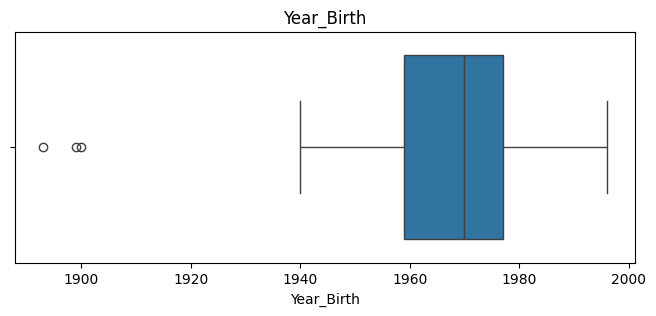

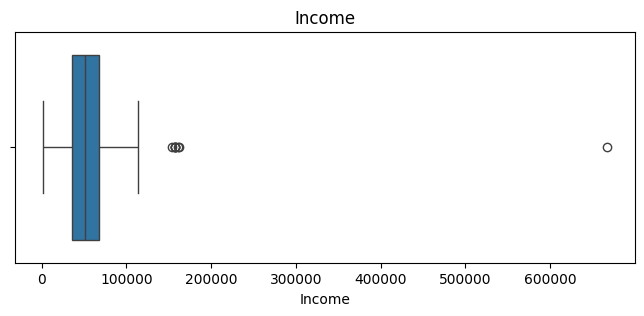

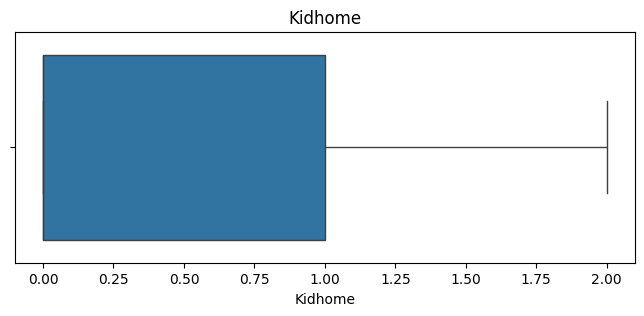

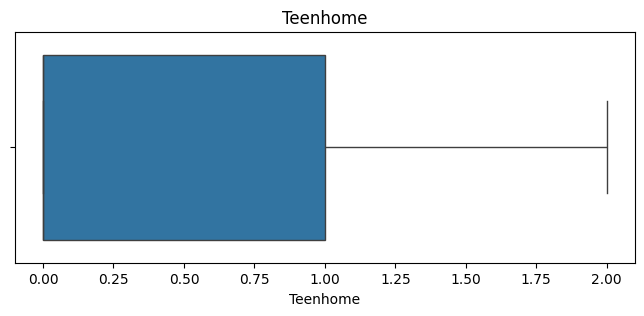

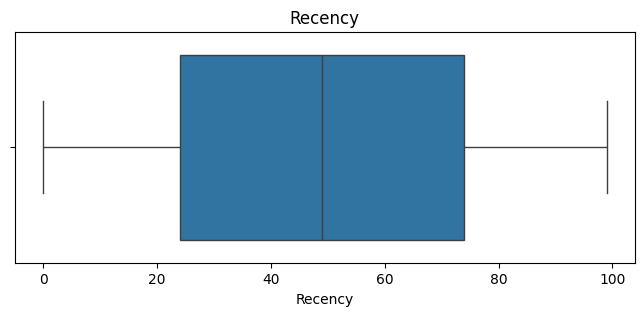

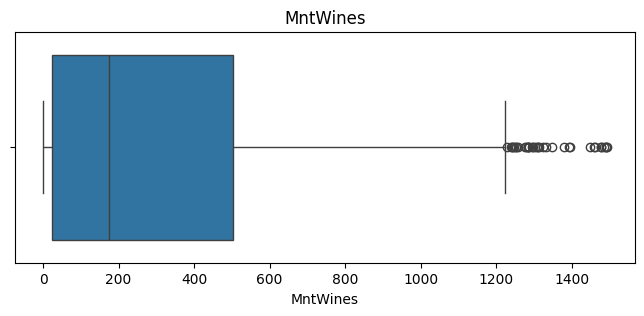

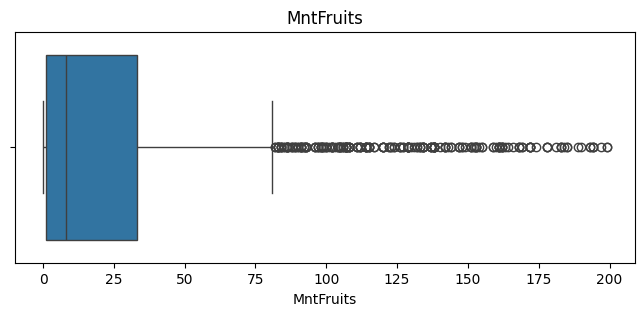

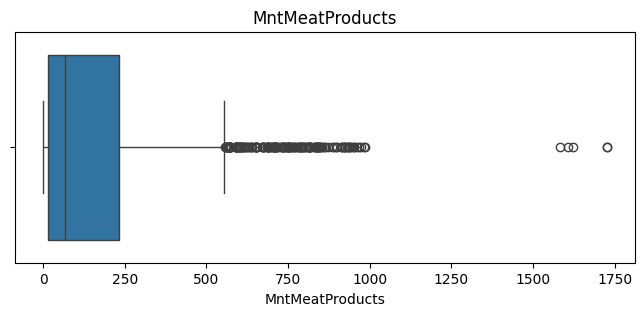

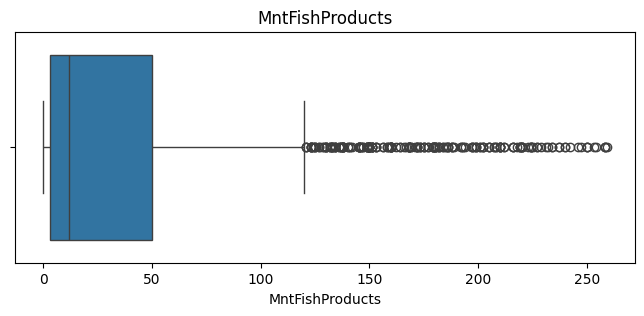

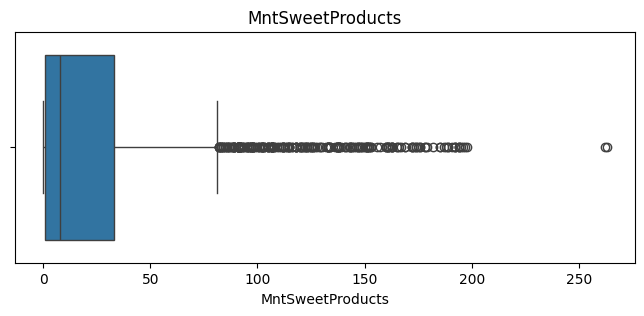

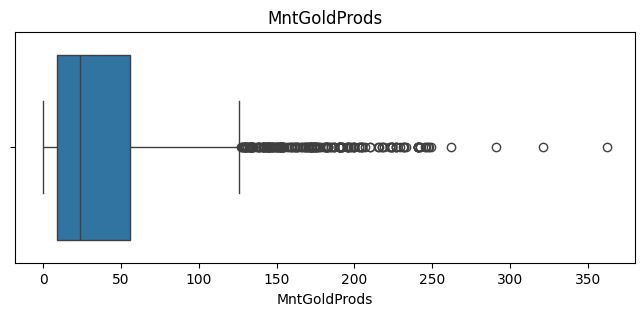

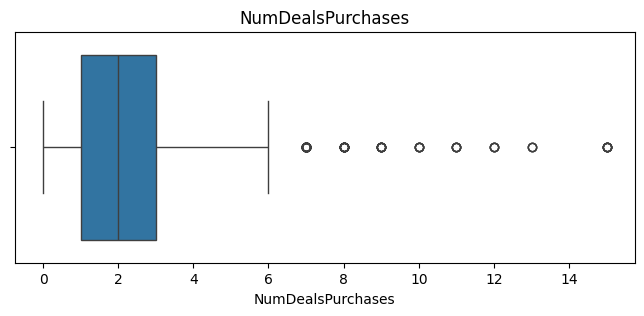

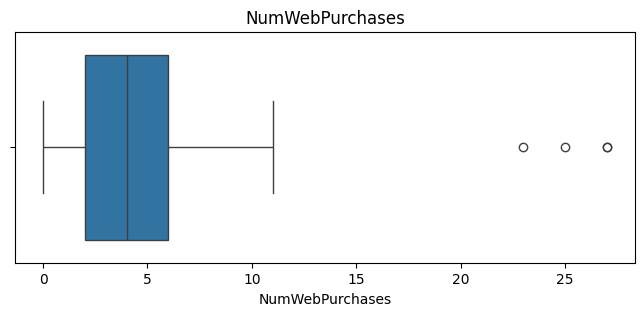

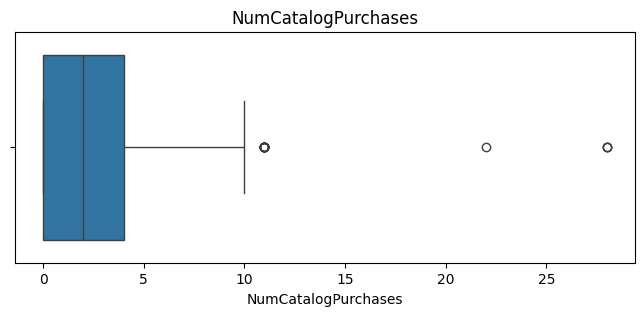

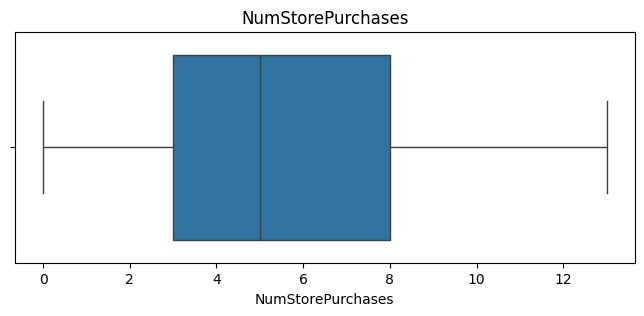

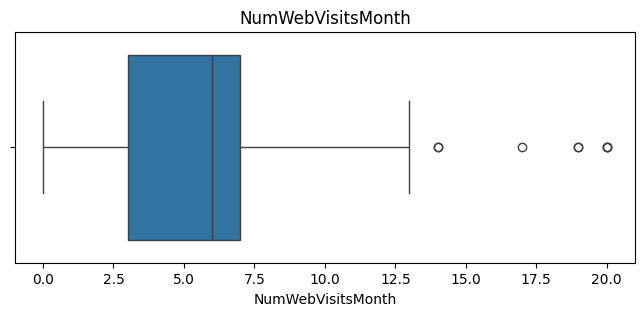

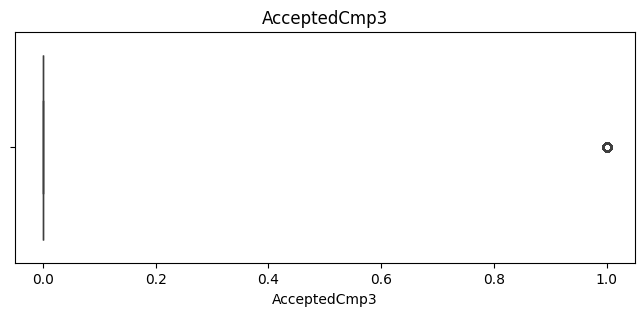

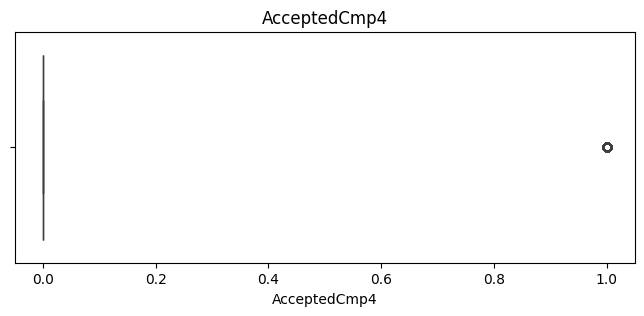

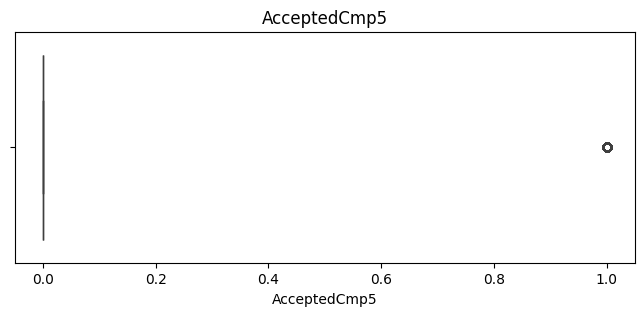

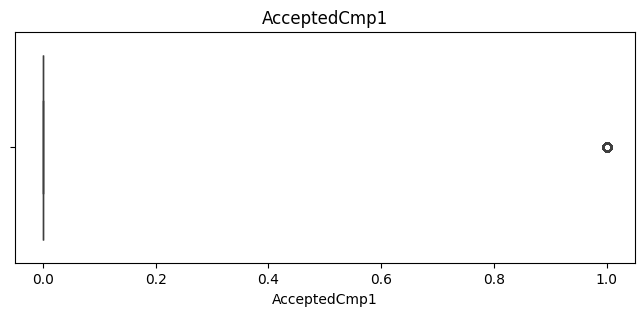

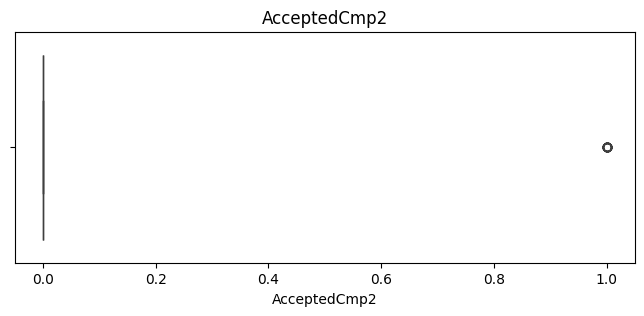

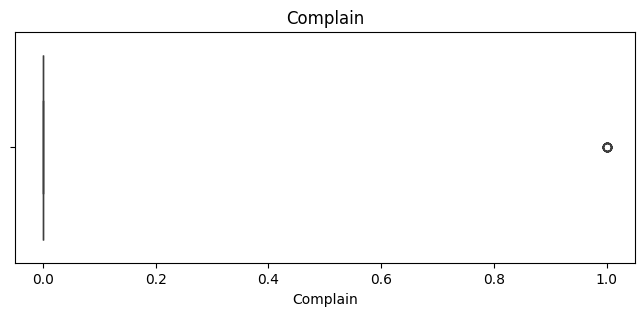

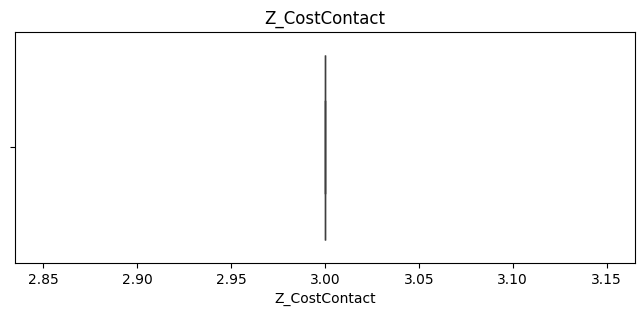

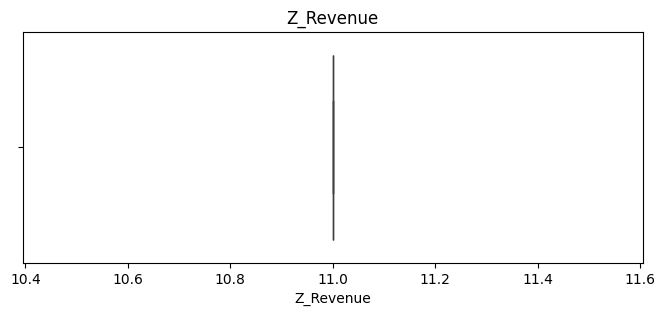

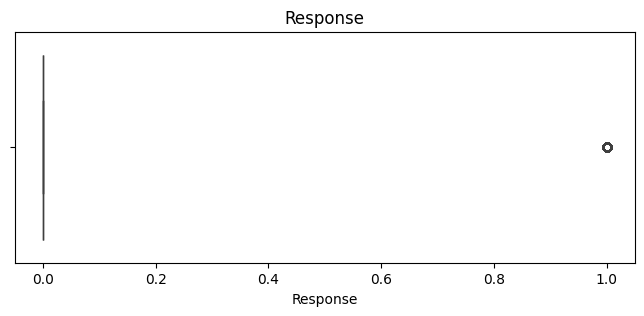

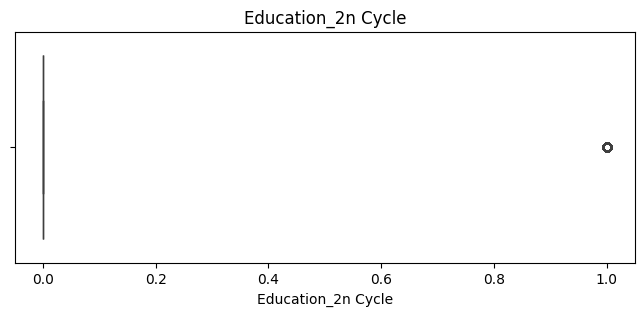

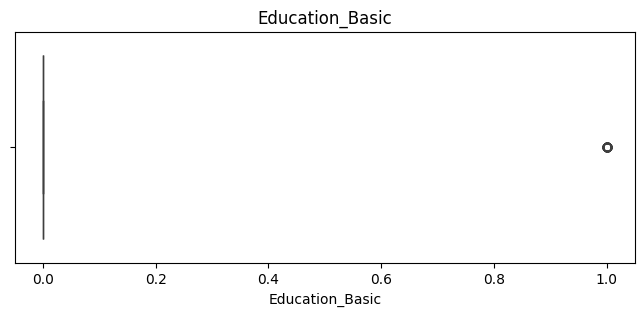

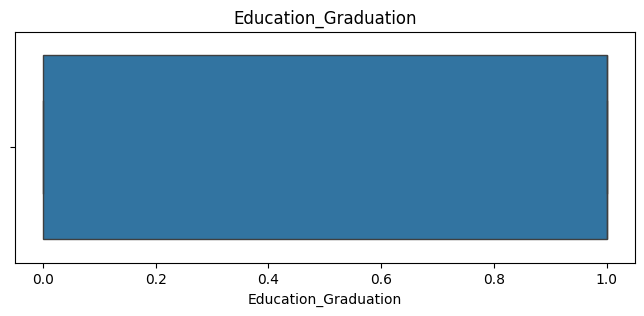

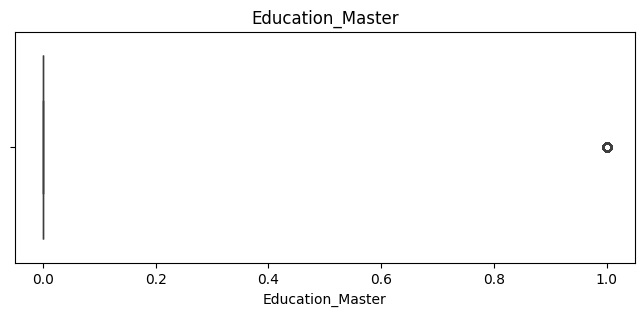

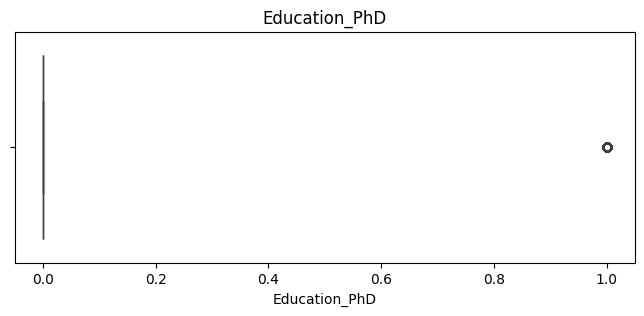

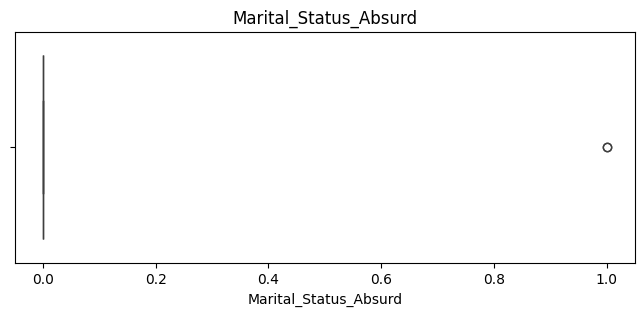

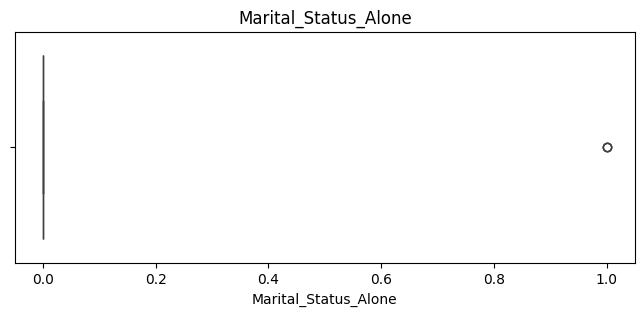

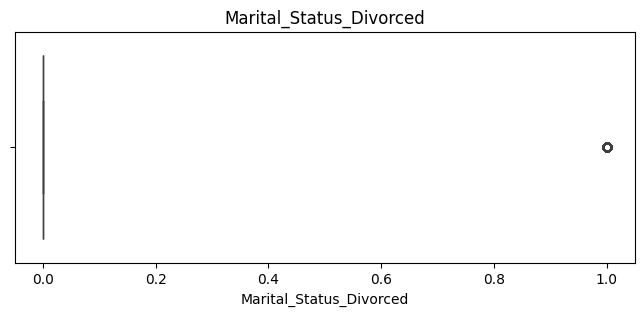

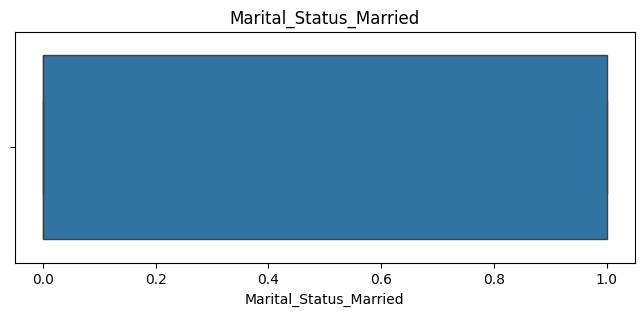

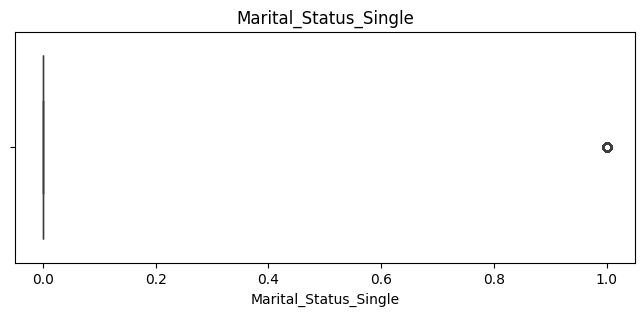

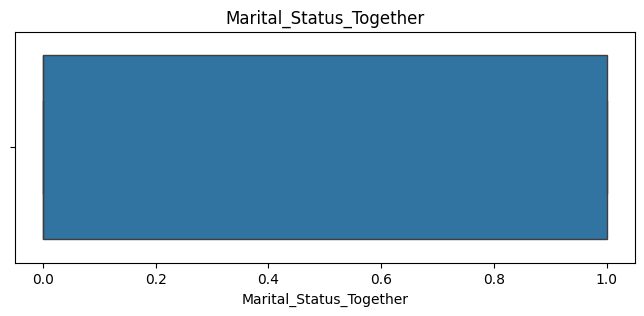

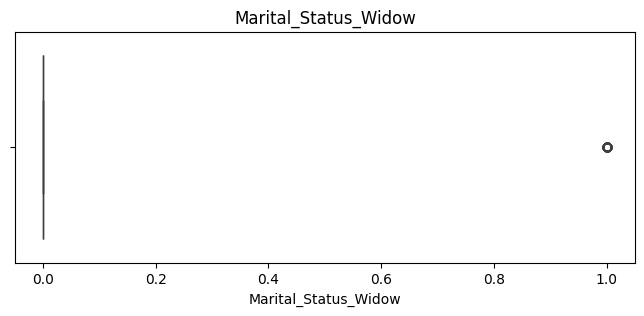

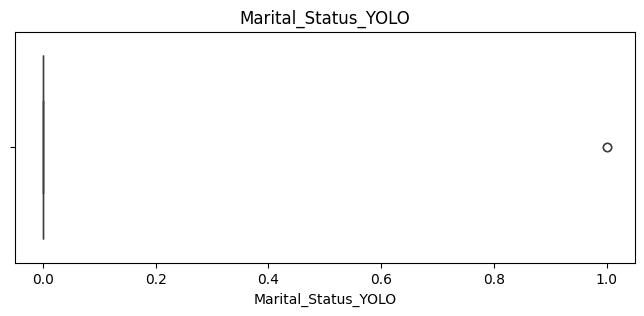

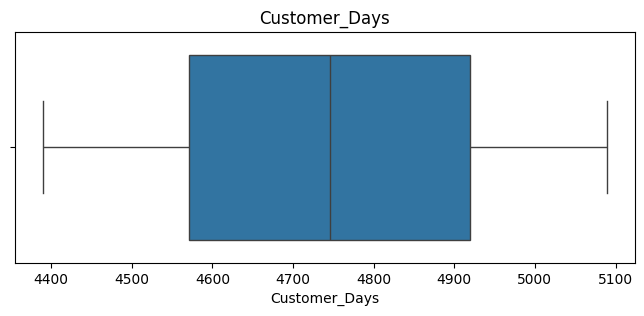

In [16]:
numerical = df.select_dtypes(include='number').columns
for col in numerical:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

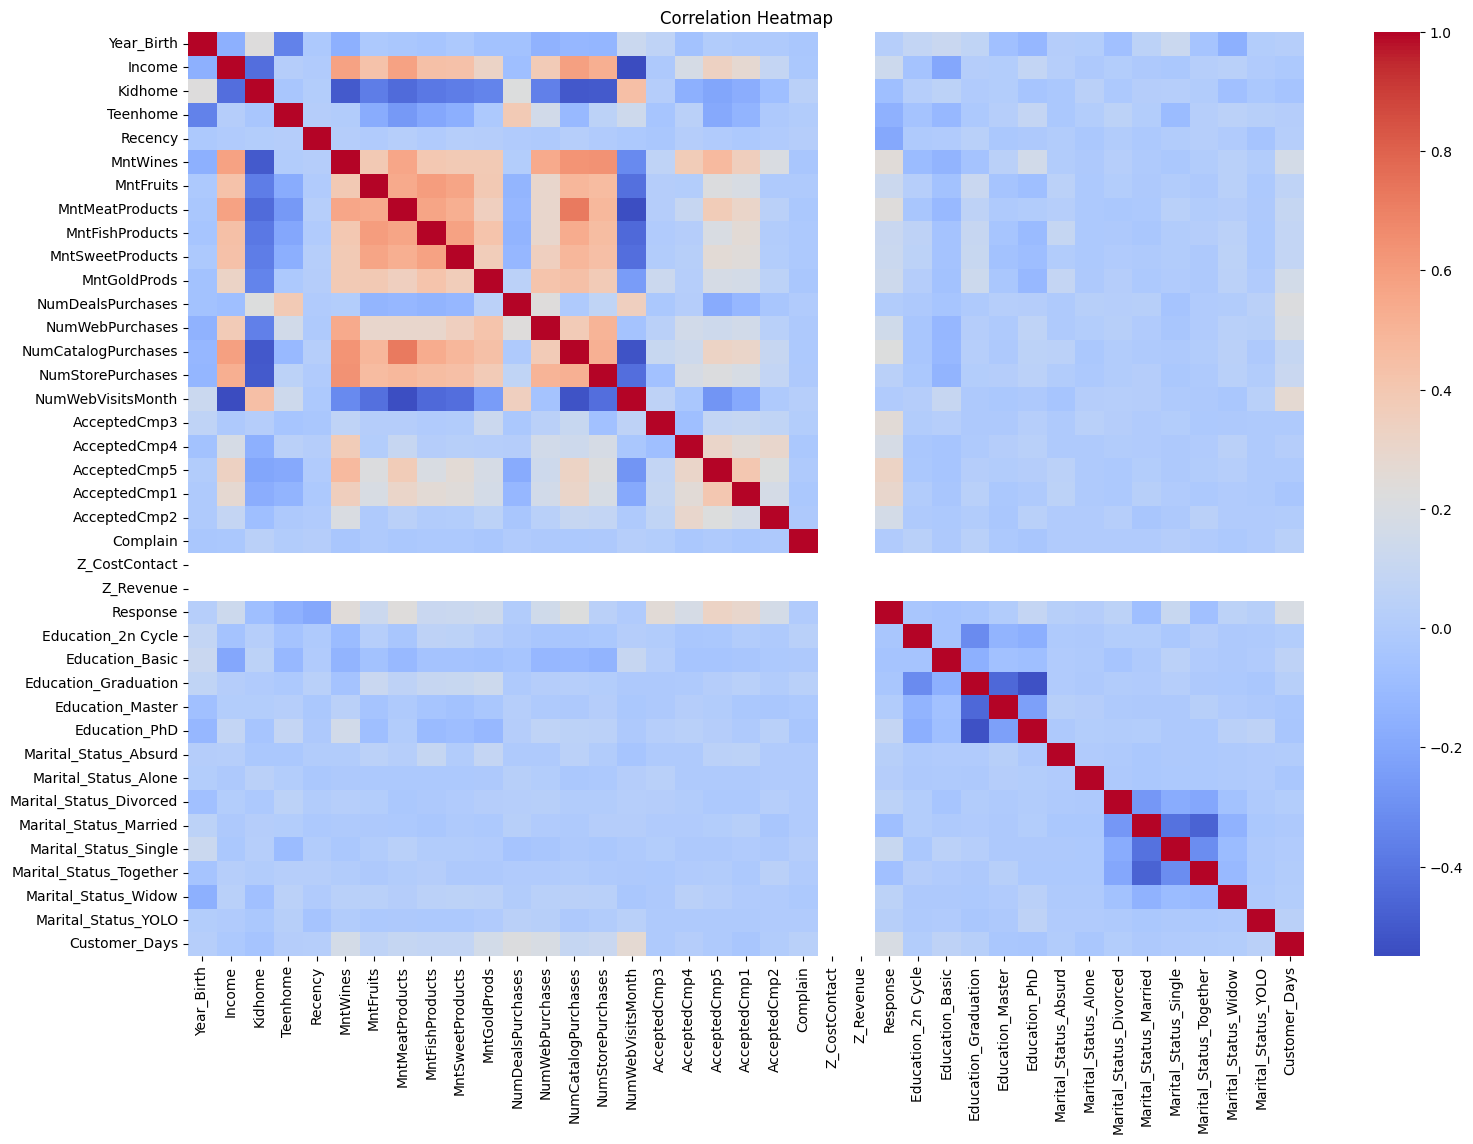

In [17]:
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
import numpy as np

df['Log_Income'] = np.log1p(df['Income'])

**Feature Engineering**

In [19]:
from datetime import datetime

current_year = datetime.now().year
df['Age'] = current_year - df['Year_Birth']

In [20]:
df['Total_Spending'] = (df['MntWines'] +df['MntFruits'] +df['MntMeatProducts'] +df['MntFishProducts'] +df['MntSweetProducts'] +df['MntGoldProds'])

In [21]:
df['Premium_Customer'] = (
    df['Income'] > df['Income'].median()
).astype(int)

In [22]:
df.drop(['Year_Birth'], axis=1, inplace=True)

df.drop(['Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)

In [23]:
print(df.columns)

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Education_2n Cycle',
       'Education_Basic', 'Education_Graduation', 'Education_Master',
       'Education_PhD', 'Marital_Status_Absurd', 'Marital_Status_Alone',
       'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow', 'Marital_Status_YOLO', 'Customer_Days',
       'Log_Income', 'Age', 'Total_Spending', 'Premium_Customer'],
      dtype='object')


**Model Tree Prdiction**

In [24]:
x= df.drop(columns=[ 'Response' ])
y = df['Response']

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Accuracy : 0.859375
Precision: 0.5441176470588235
Recall   : 0.5362318840579711
F1 Score : 0.5401459854014599

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       379
           1       0.54      0.54      0.54        69

    accuracy                           0.86       448
   macro avg       0.73      0.73      0.73       448
weighted avg       0.86      0.86      0.86       448


Top 15 Important Features

                Feature  Importance
17         AcceptedCmp5    0.130265
15         AcceptedCmp3    0.075252
12  NumCatalogPurchases    0.048373
18         AcceptedCmp1    0.047400
25        Education_PhD    0.043907


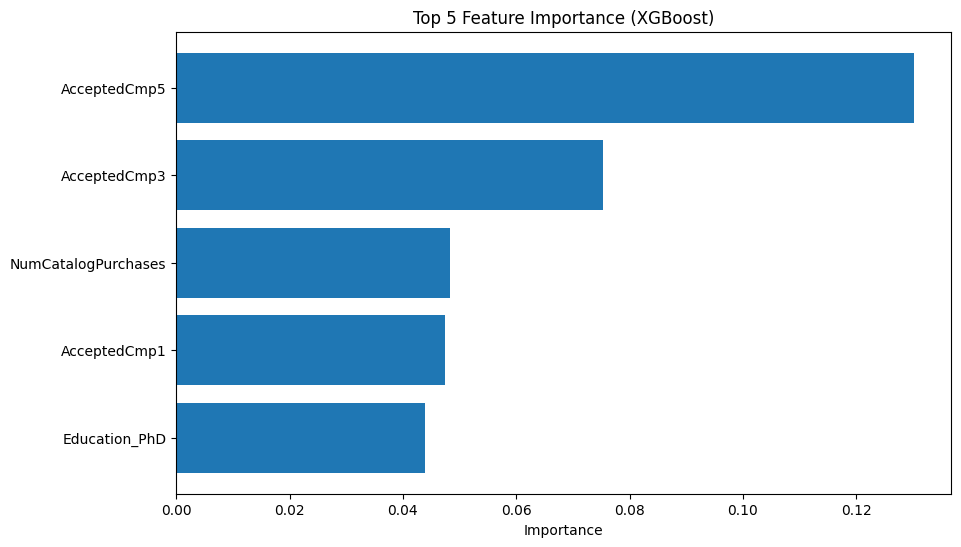

In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
# Handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# XGBoost Model
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# Train Model
model.fit(x_train, y_train)

# Prediction
y_pred = model.predict(x_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# Feature Importance
importance = model.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": x.columns,
        "Importance": importance
    })
    .sort_values("Importance", ascending=False)
)

print("\nTop 15 Important Features\n")
print(feature_importance.head(5))

# Plot Feature Importance
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance["Feature"][:5],
    feature_importance["Importance"][:5]
)
plt.gca().invert_yaxis()
plt.title("Top 5 Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.show()

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

X = df.drop('Response', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=1.2, min_samples=5)

df['Cluster'] = dbscan.fit_predict(X_scaled)

print(df['Cluster'].value_counts())

Cluster
-1    2181
 0      31
 2      11
 4       7
 1       5
 3       5
Name: count, dtype: int64


## Customer Segmentation

In [28]:
df["Total_Purchases"] = (
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

features = [
    "Income",
    "Age",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "Customer_Days",
    "NumWebVisitsMonth",

]

x= df[features]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=4.5, min_samples=12)

df['Cluster'] = dbscan.fit_predict(X_scaled)

print(df['Cluster'].value_counts())

Cluster
 0    1689
-1     453
 1      49
 2      36
 3      13
Name: count, dtype: int64


In [30]:


# Create Age only if it doesn't already exist
if 'Age' not in df.columns:
    if 'Year_Birth' in df.columns:
        df['Age'] = 2026 - df['Year_Birth']

# Create Total Spending only if it doesn't exist
if 'Total_Spending' not in df.columns:
    df['Total_Spending'] = (
        df['MntWines'] +
        df['MntFruits'] +
        df['MntMeatProducts'] +
        df['MntFishProducts'] +
        df['MntSweetProducts'] +
        df['MntGoldProds']
    )

# Create Total Purchases only if it doesn't exist
if 'Total_Purchases' not in df.columns:
    df['Total_Purchases'] = (
        df['NumWebPurchases'] +
        df['NumCatalogPurchases'] +
        df['NumStorePurchases']
    )

In [31]:
segment = df.groupby('Cluster').agg({
    'Income':'mean',
    'Age':'mean',
    'Total_Spending':'mean',
    'Total_Purchases':'mean',
    'Recency':'mean',
    'Response':'mean'
})

print(segment.round(2))

           Income    Age  Total_Spending  Total_Purchases  Recency  Response
Cluster                                                                     
-1       71674.10  59.29         1236.28            18.27    48.01      0.36
 0       47835.17  56.72          450.48            11.21    49.61      0.09
 1       19823.71  48.00           61.39             4.86    46.20      0.02
 2       48177.36  65.78          363.33            10.31    49.39      0.11
 3       80411.85  56.54         1538.31            20.77    32.08      0.38


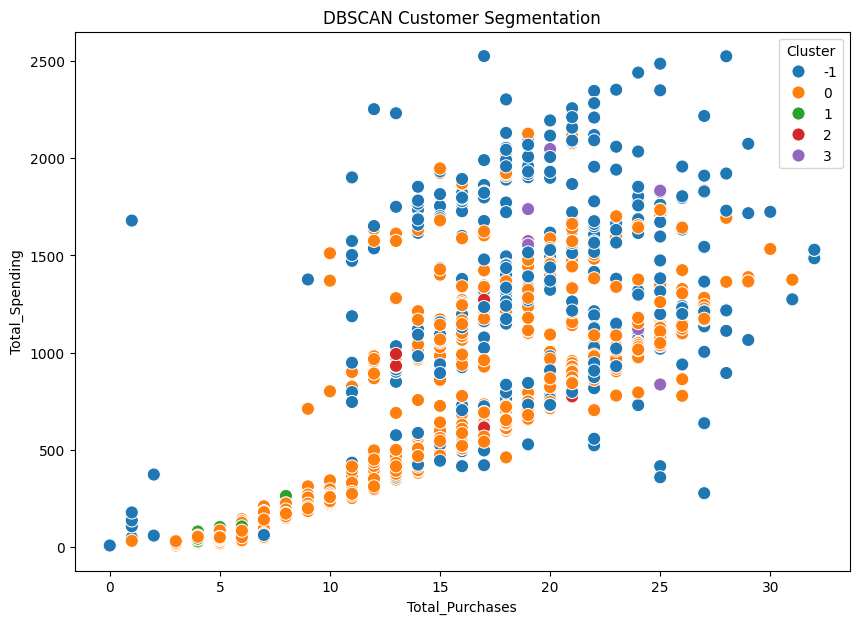

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
   x='Total_Purchases',
y='Total_Spending',
    hue='Cluster',
    palette='tab10',
    s=90)

plt.title("DBSCAN Customer Segmentation")
plt.xlabel("Total_Purchases")
plt.ylabel("Total_Spending")

plt.show()

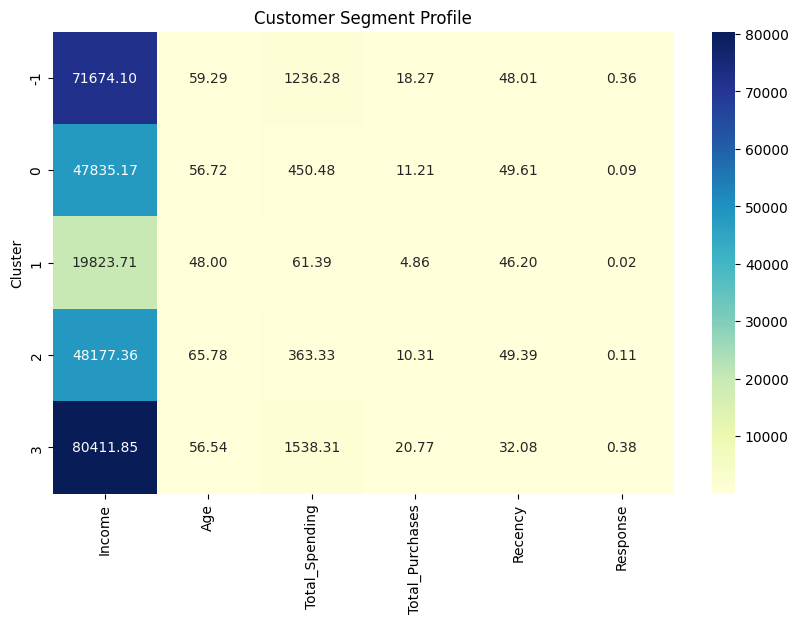

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(segment,annot=True,cmap='YlGnBu',fmt='.2f')
plt.title("Customer Segment Profile")
plt.show()

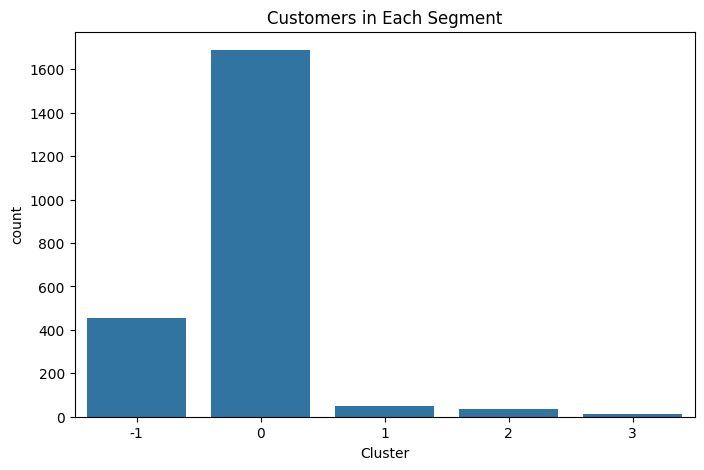

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(x='Cluster',data=df)
plt.title("Customers in Each Segment")
plt.show()

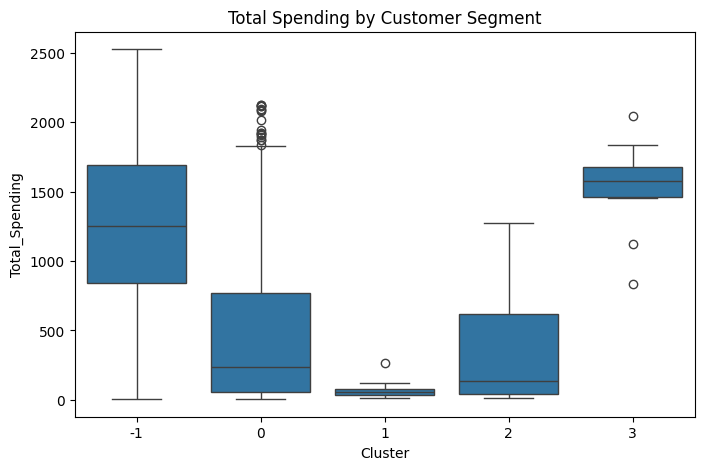

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='Cluster',y='Total_Spending')
plt.title("Total Spending by Customer Segment")
plt.show()

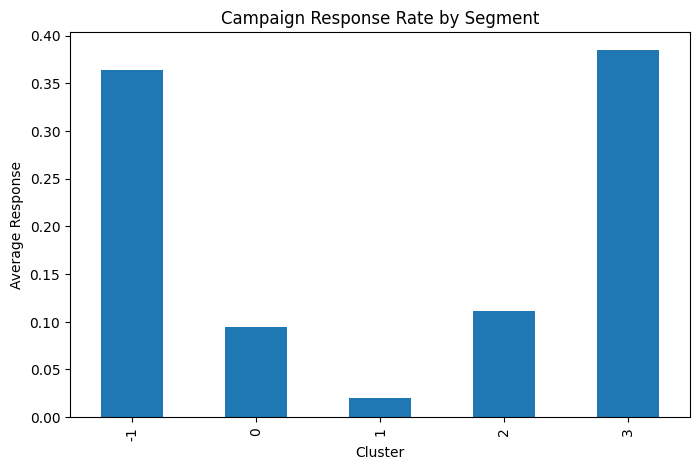

In [36]:
response = df.groupby('Cluster')['Response'].mean()
response.plot(kind='bar',figsize=(8,5))
plt.title("Campaign Response Rate by Segment")
plt.ylabel("Average Response")
plt.show()